# Semana 6 - Modelo Logístico

O artigo _Acceptable noise levels for construction site offices_ (Building Serv.Engr. Res. Tech., 2009: 87-94) analisou as respostas de uma amostra com 77 indivíduos, aos quais foi perguntado se um nível de ruído específico (dBA) em que já havia sido exposto era aceitável ou inaceitável. Eis os dados oferecidos pelos autores do artigo:

| Acceptable | Unacceptable |
|------------|--------------|
| 55.3 | 63.8 |
| 55.3 | 63.8 |
| 55.3 | 63.8 |
| 55.9 | 63.9 |
| 55.9 | 63.9 |
| 55.9 | 63.9 |
| 55.9 | 64.7 |
| 56.1 | 64.7 |
| 56.1 | 64.7 |
| 56.1 | 65.1 |
| 56.1 | 65.1 |
| 56.1 | 65.1 |
| 56.1 | 67.4 |
| 56.8 | 67.4 |
| 56.8 | 67.4 |
| 57.0 | 67.4 |
| 57.0 | 68.7 |
| 57.0 | 68.7 |
| 57.8 | 68.7 |
| 57.8 | 70.4 |
| 57.8 | 70.4 |
| 57.9 | 71.2 |
| 57.9 | 71.2 |
| 57.9 | 73.1 |
| 58.8 | 73.1 |
| 58.8 | 74.6 |
| 58.8 | 74.6 |
| 59.8 | 74.6 |
| 59.8 | 74.6 |
| 59.8 | 79.3 |
| 62.2 | 79.3 |
| 62.2 | 79.3 |
| 65.3 | 79.3 |
| 65.3 | 79.3 |
| 65.3 | 83.0 |
| 65.3 | 83.0 |
| 68.7 | 83.0 |
| 69.0 | |
| 73.0 | |
| 73.0 | |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
from statsmodels.graphics.gofplots import ProbPlot
plt.style.use('seaborn-v0_8')
plt.rc('axes', titlesize=10)

In [3]:
lstxr = (55.3,55.3,55.3,55.9,55.9,55.9,55.9,56.1,56.1,56.1,56.1,56.1,56.1,56.8,
        56.8,57.0,57.0,57.0,57.8,57.8,57.8,57.9,57.9,57.9,58.8,58.8,58.8,59.8,
        59.8,59.8,62.2,62.2,65.3,65.3,65.3,65.3,68.7,69.0,73.0,73.0,63.8,63.8,
        63.8,63.9,63.9,63.9,64.7,64.7,64.7,65.1,65.1,65.1,67.4,67.4,67.4,67.4,
        68.7,68.7,68.7,70.4,70.4,71.2,71.2,73.1,73.1,74.6,74.6,74.6,74.6,79.3,
        79.3,79.3,79.3,79.3,83.0,83.0,83.0)
lstyr= (1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,
        1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
        0,0,0,0,0,0,0)
# Construir o DataFrame e nomear as colunas
df1 = pd.DataFrame(list(zip(lstxr, lstyr)),
               columns =["x","y"])
x=df1['x']
y=df1['y']
df1.head()

,x,y
0,55.3,1
1,55.3,1
2,55.3,1
3,55.9,1
4,55.9,1


In [4]:
#adicionar uma constante preditora
x = sm.add_constant(x)
# Construir o modelo e ajustar os dados
modelo = sm.Logit(y, x).fit()
print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.353003
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   77
Model:                          Logit   Df Residuals:                       75
Method:                           MLE   Df Model:                            1
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                  0.4902
Time:                        18:08:27   Log-Likelihood:                -27.181
converged:                       True   LL-Null:                       -53.314
Covariance Type:            nonrobust   LLR p-value:                 4.849e-13
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         23.0140      5.041      4.565      0.000      13.133      32.895
x             -0.3562      0.

In [5]:
# performing predictions on the test datdaset
yhat = modelo.predict()
prediction = list(map(round, yhat))
 
# comparing original and predicted values of y
print('Valores observados:', list(y))
print('Valores previstos:', prediction)
df2 = pd.DataFrame(list(zip(y, prediction)),
               columns =["x","y"])
#df2.to_csv(index=False)


Valores observados: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Valores previstos: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [6]:
from sklearn.metrics import (confusion_matrix,accuracy_score)
 
# confusion matrix
cm = confusion_matrix(y, prediction)
print ("Confusion Matrix : \n", cm)
 
# accuracy score of the model
print('Test accuracy = ', accuracy_score(y, prediction))

Confusion Matrix : 
 [[31  6]
 [ 8 32]]
Test accuracy =  0.8181818181818182


Text(0, 0.5, 'p(x) Aceitável - Não aceitável')

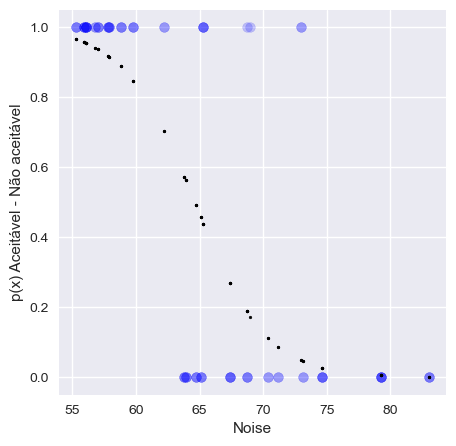

In [7]:
x=df1['x']
y=df1['y']
plt.figure(figsize=(5, 5))
ax = plt.axes()
ax.scatter(x, y, color='b', alpha=0.20)
ax.scatter(x, yhat, color="black", s=4)
ax.set_xlabel('Noise')
ax.set_ylabel('p(x) Aceitável - Não aceitável')

In [9]:
#z: estatística de teste 
zt2=modelo.tvalues
ztb1=zt2.x
ztb1

np.float64(-4.543196364190341)

In [10]:
#usar a tabela tstudent
from scipy.stats import t
#calculate p-value  TWO TAILED
p_val= (1-t.cdf(x=abs(ztb1), df=len(x))) * 2
p_val

np.float64(2.0197364118068606e-05)

In [13]:
#Obter a razão das chances
odd=np.exp(modelo.params)
#odd[1]
odd.x

np.float64(0.7003306991172537)

In [15]:
params = modelo.params
conf = modelo.conf_int()
conf['Odds Ratio'] = params
conf.columns = ['5%', '95%', 'Odds Ratio']
print(np.exp(conf))


                  5%           95%    Odds Ratio
const  505293.279605  1.932709e+14  9.882230e+09
x           0.600573  8.166583e-01  7.003307e-01
